In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Hackatons/Я пофессионал/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Hackatons/Я пофессионал/test.csv')
train.shape, test.shape

((309, 12), (133, 11))

In [3]:
train.head()

,Tectonic regime,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Period,Lithology,Gross,Netpay,Porosity,Permeability
0,STRIKE-SLIP/TRANSPRESSION/BASEMENT-I,OFFSHORE,OIL,DEVELOPING,INVERSION/WRENCH,3520,NEOGENE,SANDSTONE,2460.0,220.0,20.0,45.0
1,GRAVITY/EXTENSION/EVAPORITE,OFFSHORE,OIL,MATURE PRODUCTION,SALT/PASSIVE MARGIN,9967,CRETACEOUS,LIMESTONE,427.0,160.0,19.0,175.0
2,GRAVITY/EXTENSION/EVAPORITE,ONSHORE,OIL,MATURE PRODUCTION,PASSIVE MARGIN,8700,CRETACEOUS,LIMESTONE,95.0,15.0,12.0,20.0
3,COMPRESSION,ONSHORE,OIL,DECLINING PRODUCTION,THRUST,5084,CRETACEOUS,SANDSTONE,328.0,300.0,13.0,600.0
4,INVERSION/COMPRESSION/EXTENSION,ONSHORE,OIL,DECLINING PRODUCTION,INVERSION/RIFT,1030,CRETACEOUS,SANDSTONE,260.0,33.0,24.0,182.0


In [8]:
cat_cols = ['Tectonic regime', 'Hydrocarbon type', 'Reservoir status', 'Structural setting', 'Period', 'Lithology']
num_cols = ['Depth', 'Gross', 'Netpay', 'Porosity', 'Permeability']
target_col = ['Onshore/Offshore']

In [18]:
print('Train NaN`s:\n', train.isna().any(), '\n\nTest NaN`s:\n', test.isna().any())

Train NaN`s:
 Tectonic regime       False
Onshore/Offshore      False
Hydrocarbon type      False
Reservoir status      False
Structural setting    False
Depth                 False
Period                False
Lithology             False
Gross                 False
Netpay                False
Porosity              False
Permeability          False
dtype: bool 

Test NaN`s:
 Tectonic regime       False
Hydrocarbon type      False
Reservoir status      False
Structural setting    False
Depth                 False
Period                False
Lithology             False
Gross                 False
Netpay                False
Porosity              False
Permeability          False
dtype: bool


In [15]:
print('Train types:\n', train.dtypes, '\n\nTest types:\n', test.dtypes)

Train types:
 Tectonic regime        object
Onshore/Offshore       object
Hydrocarbon type       object
Reservoir status       object
Structural setting     object
Depth                   int64
Period                 object
Lithology              object
Gross                 float64
Netpay                float64
Porosity              float64
Permeability          float64
dtype: object 

Test types:
 Tectonic regime        object
Hydrocarbon type       object
Reservoir status       object
Structural setting     object
Depth                   int64
Period                 object
Lithology              object
Gross                 float64
Netpay                float64
Porosity              float64
Permeability          float64
dtype: object


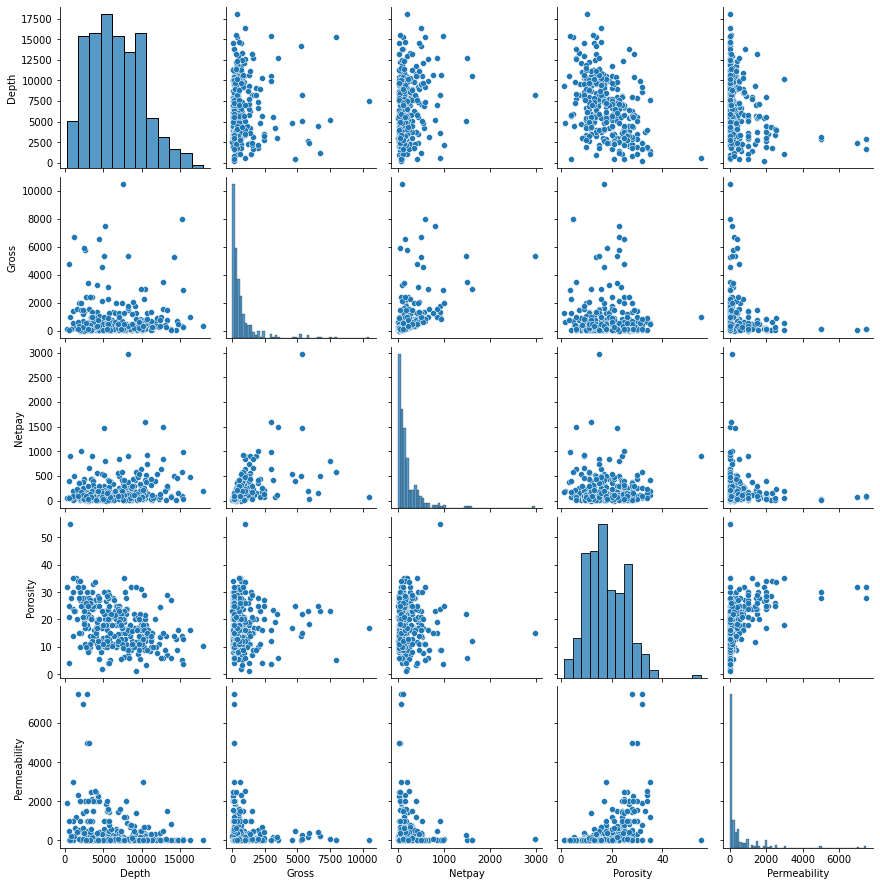

In [29]:
sns.pairplot(train[num_cols])
None

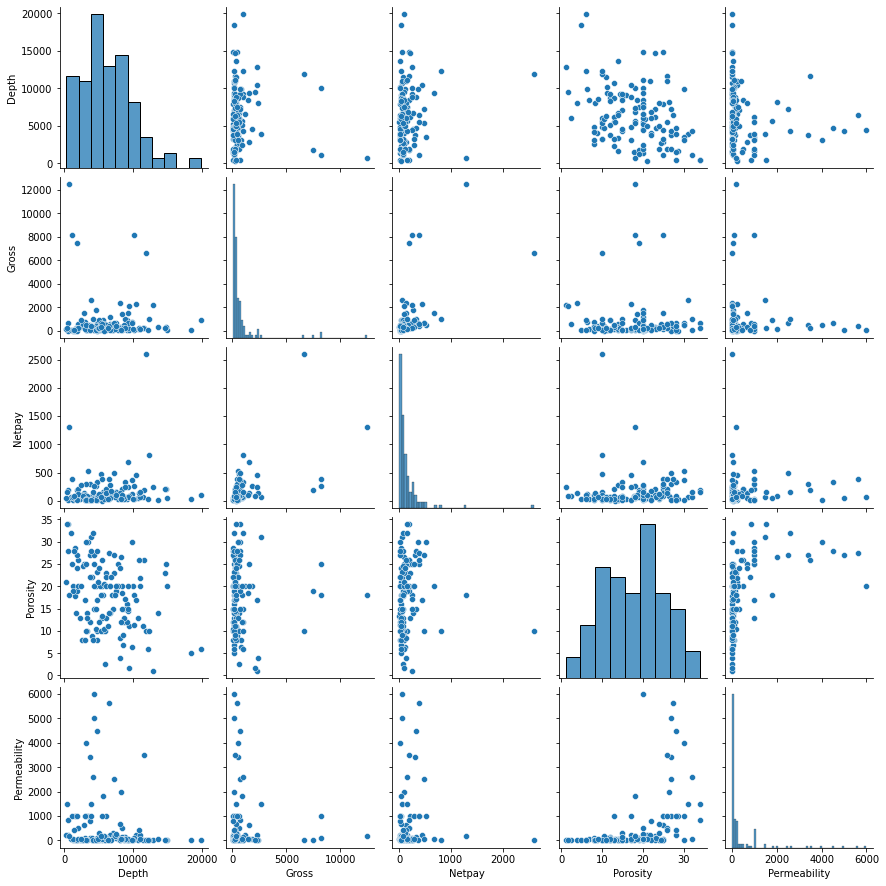

In [37]:
sns.pairplot(test[num_cols])
None

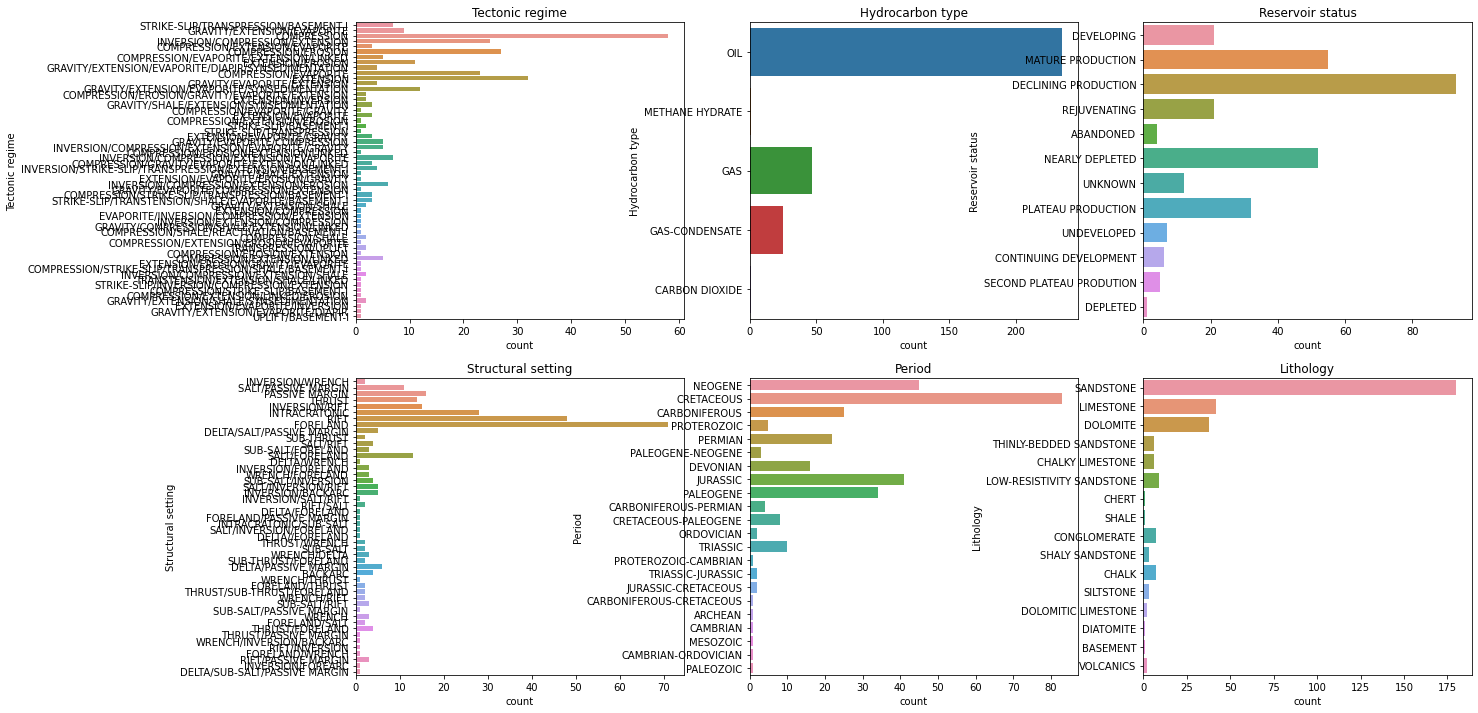

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for i, cat in enumerate(cat_cols):
    axes[i // 3, i % 3].set_title(cat)
    sns.countplot(data=train, y=cat, ax=axes[i // 3, i % 3])

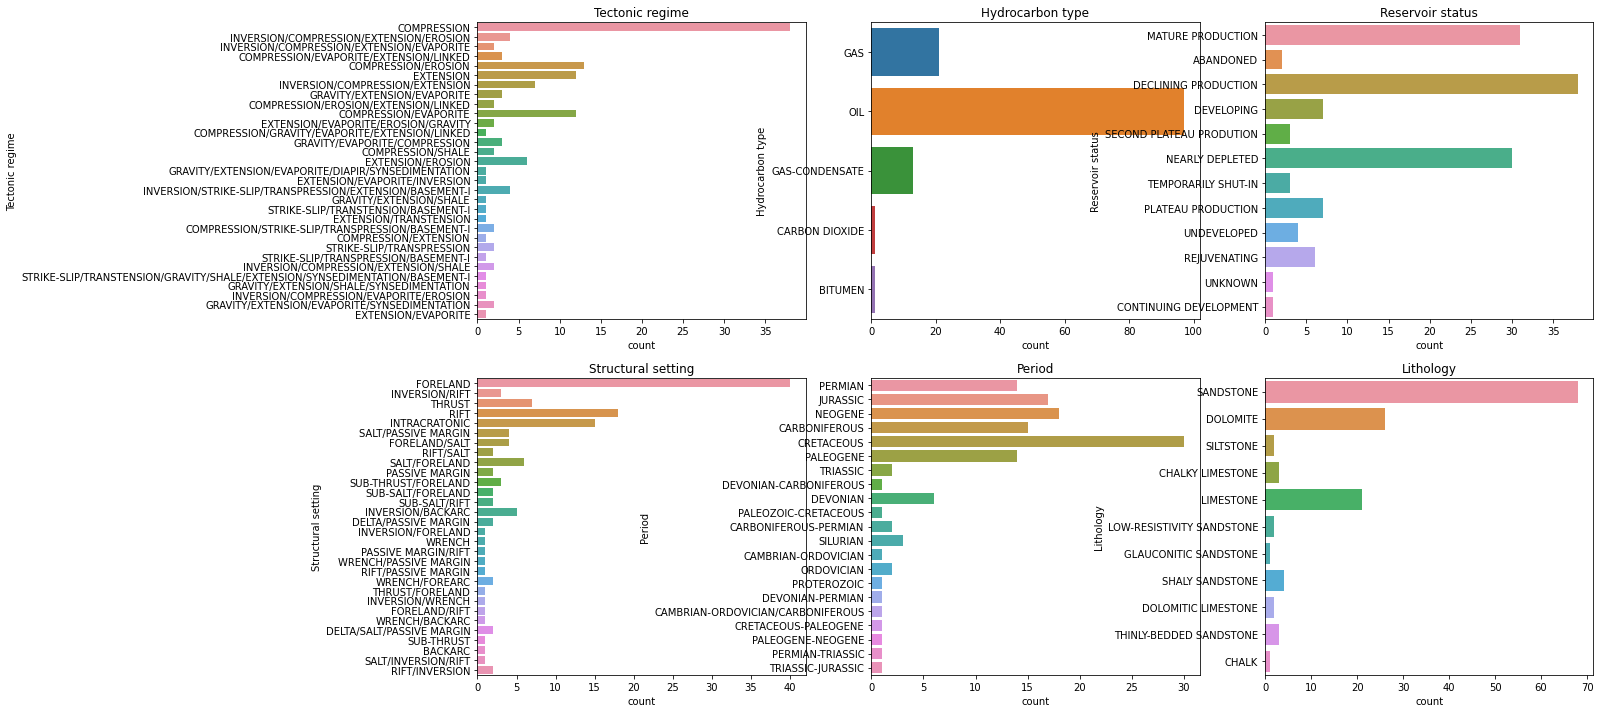

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for i, cat in enumerate(cat_cols):
    axes[i // 3, i % 3].set_title(cat)
    sns.countplot(data=test, y=cat, ax=axes[i // 3, i % 3])

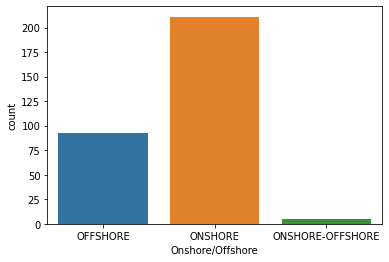

In [57]:
sns.countplot(data=train, x=target_col[0])
None

In [67]:
X_train = train.drop(target_col, axis=1)
y_train = train[target_col]

In [70]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import make_column_transformer

In [68]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train.to_numpy().reshape(-1))

# LogReg

In [78]:
column_transformer = make_column_transformer(
    (StandardScaler(), num_cols),
    (OneHotEncoder(handle_unknown='ignore'), cat_cols)
)

pipeline = make_pipeline(
    column_transformer,
    LogisticRegression(random_state=0, class_weight='balanced', max_iter=1000)
)

pipeline.get_params().keys()

dict_keys(['memory', 'steps', 'verbose', 'columntransformer', 'logisticregression', 'columntransformer__n_jobs', 'columntransformer__remainder', 'columntransformer__sparse_threshold', 'columntransformer__transformer_weights', 'columntransformer__transformers', 'columntransformer__verbose', 'columntransformer__standardscaler', 'columntransformer__onehotencoder', 'columntransformer__standardscaler__copy', 'columntransformer__standardscaler__with_mean', 'columntransformer__standardscaler__with_std', 'columntransformer__onehotencoder__categories', 'columntransformer__onehotencoder__drop', 'columntransformer__onehotencoder__dtype', 'columntransformer__onehotencoder__handle_unknown', 'columntransformer__onehotencoder__sparse', 'logisticregression__C', 'logisticregression__class_weight', 'logisticregression__dual', 'logisticregression__fit_intercept', 'logisticregression__intercept_scaling', 'logisticregression__l1_ratio', 'logisticregression__max_iter', 'logisticregression__multi_class', 'lo

In [79]:
params = {
    'logisticregression__C': [0.1, 1, 10, 100]
}

grid = GridSearchCV(pipeline, params, scoring='accuracy').fit(X_train, y_train)

In [80]:
grid.best_score_

0.7671602326811211

In [84]:
preds = grid.best_estimator_.predict(test)
preds = label_encoder.inverse_transform(preds)

# CatBoost

In [89]:
!pip install catboost

     |████████████████████████████████| 66.3MB 57kB/s 


In [90]:
import catboost

In [98]:
X_tt, X_tv, y_tt, y_tv = train_test_split(X_train, y_train, test_size=0.2, random_state=0)
eval_dataset = catboost.Pool(X_tv, y_tv, cat_features=cat_cols)
model = catboost.CatBoostClassifier(n_estimators=1000, cat_features=cat_cols, 
                                    loss_function='MultiClass', 
                                    eval_metric='Accuracy', random_seed=0)

params = {
    'learning_rate': [0.01, 0.1, 1],
    'depth': [6, 8, 10]
}

model.grid_search(params, X_train, y_train)


bestTest = 0.9032258065
bestIteration = 962

0:	loss: 0.9032258	best: 0.9032258 (0)	total: 10.2s	remaining: 1m 21s

bestTest = 0.9193548387
bestIteration = 244

1:	loss: 0.9193548	best: 0.9193548 (1)	total: 21.2s	remaining: 1m 14s

bestTest = 0.8709677419
bestIteration = 537

2:	loss: 0.8709677	best: 0.9193548 (1)	total: 32.2s	remaining: 1m 4s

bestTest = 0.8870967742
bestIteration = 769

3:	loss: 0.8870968	best: 0.9193548 (1)	total: 57.7s	remaining: 1m 12s

bestTest = 0.9032258065
bestIteration = 393

4:	loss: 0.9032258	best: 0.9193548 (1)	total: 1m 25s	remaining: 1m 8s

bestTest = 0.8709677419
bestIteration = 329

5:	loss: 0.8709677	best: 0.9193548 (1)	total: 1m 52s	remaining: 56.4s

bestTest = 0.8709677419
bestIteration = 328

6:	loss: 0.8709677	best: 0.9193548 (1)	total: 3m 21s	remaining: 57.5s

bestTest = 0.8870967742
bestIteration = 270

7:	loss: 0.8870968	best: 0.9193548 (1)	total: 5m 2s	remaining: 37.8s

bestTest = 0.8225806452
bestIteration = 991

8:	loss: 0.8225806	best: 0.9

{'cv_results': defaultdict(list,
             {'iterations': [0,
               1,
               2,
               3,
               4,
               5,
               6,
               7,
               8,
               9,
               10,
               11,
               12,
               13,
               14,
               15,
               16,
               17,
               18,
               19,
               20,
               21,
               22,
               23,
               24,
               25,
               26,
               27,
               28,
               29,
               30,
               31,
               32,
               33,
               34,
               35,
               36,
               37,
               38,
               39,
               40,
               41,
               42,
               43,
               44,
               45,
               46,
               47,
               48,
               49,
             

In [99]:
model.get_params()

{'cat_features': ['Tectonic regime',
  'Hydrocarbon type',
  'Reservoir status',
  'Structural setting',
  'Period',
  'Lithology'],
 'depth': 6,
 'eval_metric': 'Accuracy',
 'learning_rate': 0.1,
 'loss_function': 'MultiClass',
 'n_estimators': 1000,
 'random_seed': 0}

In [100]:
preds = model.predict(test)
preds = label_encoder.inverse_transform(preds)

/usr/local/lib/python3.6/dist-packages/sklearn/preprocessing/_label.py:289: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [101]:
preds

array(['ONSHORE', 'ONSHORE', 'ONSHORE', 'OFFSHORE', 'ONSHORE', 'ONSHORE',
       'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE', 'OFFSHORE', 'ONSHORE',
       'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE',
       'ONSHORE', 'OFFSHORE', 'ONSHORE', 'ONSHORE', 'OFFSHORE',
       'OFFSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE',
       'OFFSHORE', 'OFFSHORE', 'OFFSHORE', 'ONSHORE', 'OFFSHORE',
       'ONSHORE', 'OFFSHORE', 'ONSHORE', 'OFFSHORE', 'ONSHORE', 'ONSHORE',
       'OFFSHORE', 'OFFSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE',
       'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE', 'OFFSHORE',
       'ONSHORE', 'ONSHORE-OFFSHORE', 'OFFSHORE', 'ONSHORE', 'ONSHORE',
       'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE',
       'ONSHORE', 'ONSHORE', 'OFFSHORE', 'ONSHORE', 'OFFSHORE', 'ONSHORE',
       'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE',
       'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHORE', 'ONSHOR

# Вывод

In [103]:
preds = pd.DataFrame(preds)
preds.to_csv('/content/drive/MyDrive/Colab Notebooks/Hackatons/Я пофессионал/prediction.csv', index=False, header=False)